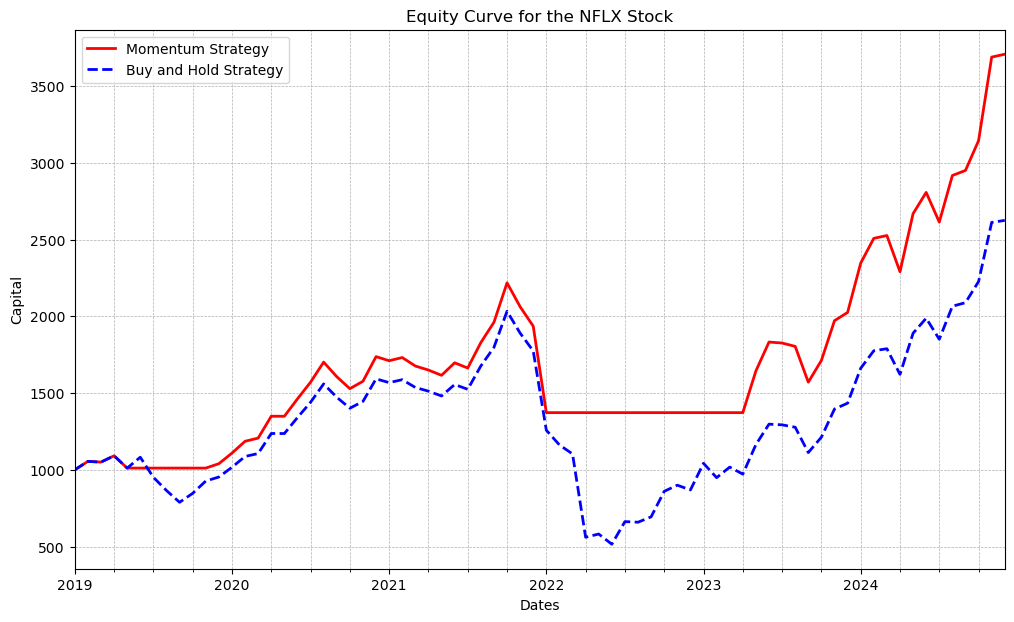

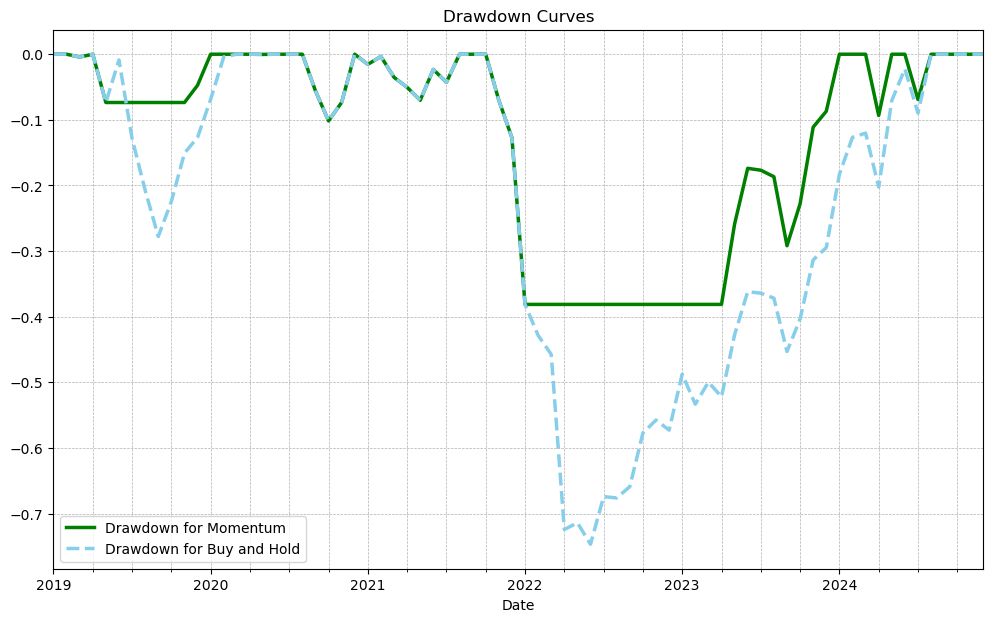

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from Fonctions import compute_metrics, drawdown
%load_ext autoreload
%autoreload 2

data_return = pd.read_csv("NFLX_data_return.csv", index_col=0, parse_dates=True).squeeze()
monthly_return = data_return.resample("ME").sum()
signal = monthly_return.rolling(12).sum()
invest = (signal > 0).astype(int).shift(1)
strat = monthly_return * invest

V0 = 1000
equity_curve = V0 * np.exp(strat.cumsum())
equity_curve = equity_curve["2019-01-31":]
equity_curve = equity_curve / equity_curve.iloc[0] * V0

equity_bandh = V0 * np.exp(monthly_return.cumsum())
equity_bandh = equity_bandh["2019-01-31":]
equity_bandh = equity_bandh / equity_bandh.iloc[0] * V0

plt.figure(figsize=(12,7))
equity_curve.plot(color="red", linewidth=2, label="Momentum Strategy")
equity_bandh.plot(color="blue", linewidth=2, label="Buy and Hold Strategy", linestyle="--")
plt.title("Equity Curve for the NFLX Stock")
plt.xlabel("Dates")
plt.ylabel("Capital")
plt.legend()
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.show()

plt.figure(figsize=(12,7))
drawdown(equity_curve).plot(color="green", linewidth=2.5, label="Drawdown for Momentum")
drawdown(equity_bandh).plot(color="skyblue", linewidth=2.5, label="Drawdown for Buy and Hold", linestyle="--")
plt.title("Drawdown Curves")
plt.legend()
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.show()

monthly_return_filtered = monthly_return["2019-01-31":]
strat_filtered = strat["2019-01-31":]
pd.DataFrame({
    "Momentum": compute_metrics(strat_filtered, equity_curve, freq ="monthly"),
    "Buy and Hold": compute_metrics(monthly_return_filtered, equity_bandh, freq="monthly")
})
compute_metrics(strat_filtered, equity_curve, freq="monthly").to_csv("metrics_momentum.csv")